In [2]:
import pandas as pd
melanoma_cells = pd.read_csv("mapped_cell_types.csv")
hits = pd.read_csv("motif_hits_wide.csv")
hits.head()

,patient,FOV,cell1,cell2,cell3,cell4
0,3,FOV10,7442,7423,7486,7359
1,10,FOV118,1685,1848,1662,1796
2,10,FOV118,1764,1652,1715,1631
3,10,FOV118,9160,9526,9329,9630
4,4,FOV14,5361,5396,5244,5250


In [164]:
group_colors = {
    'percentage': 'lightgray',
    'NN': 'skyblue',
    'NP': 'salmon',
    'PP': 'lightgreen',
    'PN': 'orange'
    }

pred_map = {'unidentified': 'unidentified',
 'memory%cd4 t cell': 'memory%cd4 t cell',
 'hevs': 'hevs',
 'cd8 t cell': 'cd8 t cell',
 'cd4 t cell': 'cd4 t cell',
 'cd45ra+mhc2+': 'b cell',
 'nk cell': 'nk cell',
 'mac': 'mac',
 'blood vessels': 'blood vessels',
 'sma': 'stroma',
 'cd4 apc': 'cd4 t cell',
 'b cell': 'b cell',
 'dcs': 'dcs',
 'collagen_sma': 'stroma',
 'mono_cd14_dr': 'mac',
 'collagen': 'stroma',
 'neutrophil': 'neutrophil',
 'cd4 treg%cd4 t cell': 'Treg',
 'dc sign mac': 'mac',
 'cd206_mac': 'mac',
 'follicular_germinal_b_cell': 'gc',
 'tfh%cd4 t cell': 'cd4 t cell',
 'cd14_cd11c_dcs': 'dcs',
 'cd68_mac': 'mac',
 'cd11_cd11c_dcsign_dcs': 'dcs',
 'tumor': 'tumor'}


In [4]:
sub_class = melanoma_cells[['pred','pred_mapped','Group','cell_id']].groupby(['pred_mapped','pred','Group']).count().sort_values(by='pred_mapped', ascending=False)

In [ ]:
melanoma_cells = melanoma_cells[melanoma_cells['Group'].isin(['NN', 'NP'])]


In [59]:
groups = ['NN','NP']
percent_counts.drop([c for c in percent_counts.columns if c not in groups and c != 'pred_mapped'], axis=1, inplace=True)

In [158]:
import math
import pandas as pd

def analyze_cell_type(cells, hits, groups=None, pms=None, color_map=None, pred_map=None):
    import matplotlib.pyplot as plt

    if groups:
        cells = cells[cells['Group'].isin(groups)]
        pms = pms.drop([c for c in pms.columns if c not in groups and 'pred' not in c], axis=1, inplace=False)

    # identify columns in hits that represent node ids (columns starting with "cell")
    cell_cols = [c for c in hits.columns if c.lower().startswith("cell")]
    if not cell_cols:
        return

    # 4 panels per figure (2x2)
    panels_per_fig = 4
    for start in range(0, len(cell_cols), panels_per_fig):
        fig_cols = 2
        fig_rows = 2
        fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(12, 8))
        axes = axes.flatten()

        for i in range(panels_per_fig):
            idx = start + i
            ax = axes[i]
            if idx >= len(cell_cols):
                ax.axis('off')
                continue

            col = cell_cols[idx]
            # get cell ids for this column
            hits_melted = hits[['patient', 'FOV', col]].rename(columns={col: 'cell_id'})

            # merge with cells on FOV/fov and cell_id
            merged = pd.merge(hits_melted, cells, left_on=['FOV', 'cell_id'], right_on=['fov', 'cell_id'], how='left')

            if merged['pred'].dropna().empty:
                ax.set_title(f"{col} (no matches)")
                ax.axis('off')
                continue

            # counts and percentage
            counts = merged['pred'].value_counts(dropna=True).reset_index()
            counts.columns = ['pred', 'count']
            counts['percentage'] = counts['count'] / counts['count'].sum() * 100
            pred_mapped = pred_map.get(counts['pred'][0].lower(), counts['pred'][0])
            # merge with pms (which may add NN/NP/PN/PP columns)
            if pms is not None:
                pms_filtered = pms[pms['pred_mapped'] == pred_mapped]

                merged_df = pd.merge(counts, pms_filtered, on='pred', how='right')
            else:
                merged_df = counts

            merged_df.drop(['count'], axis=1, inplace=True)
            # ensure numeric columns are plotted; fill NaN with 0
            numeric_cols = merged_df.select_dtypes(include='number').columns.tolist()
            if not numeric_cols:
                ax.set_title(f"{col} (no numeric columns to plot)")
                ax.axis('off')
                continue

            merged_df[numeric_cols] = merged_df[numeric_cols].fillna(0)

            # set index to pred for plotting all numeric columns
            plot_df = merged_df.set_index('pred')[numeric_cols]

            # plot all numeric columns as grouped bars
            # If color_map is provided, map column names to colors
            colors = None
            if color_map is not None:
                # Only map colors for columns present in plot_df
                colors = [color_map.get(col, None) for col in plot_df.columns]
            plot_df.plot(kind='bar', ax=ax, stacked=False, color=colors)
            ax.set_title(f'Cell Type Distribution for {col}')
            ax.set_xlabel('')
            ax.set_ylabel('value (counts / percent / pm cols)')
            ax.legend(title='metric')

        plt.tight_layout()
        plt.show()

In [148]:
import matplotlib.pyplot as plt

flat = sub_class.reset_index().rename(columns={'cell_id': 'count'})

# put count as the third column (pred_mapped, pred, count, Group)
flat = flat[['pred_mapped', 'pred', 'count', 'Group']]

# Calculate total counts per pred_mapped and Group for percentage
flat['total'] = flat.groupby(['pred_mapped', 'Group'])['count'].transform('sum')
flat['percent'] = flat['count'] / flat['total'] * 100

# pivot so each Group is a separate column for plotting percentages
percent_counts = flat.pivot_table(index=['pred_mapped', 'pred'], columns='Group', values='percent', fill_value=0).reset_index()


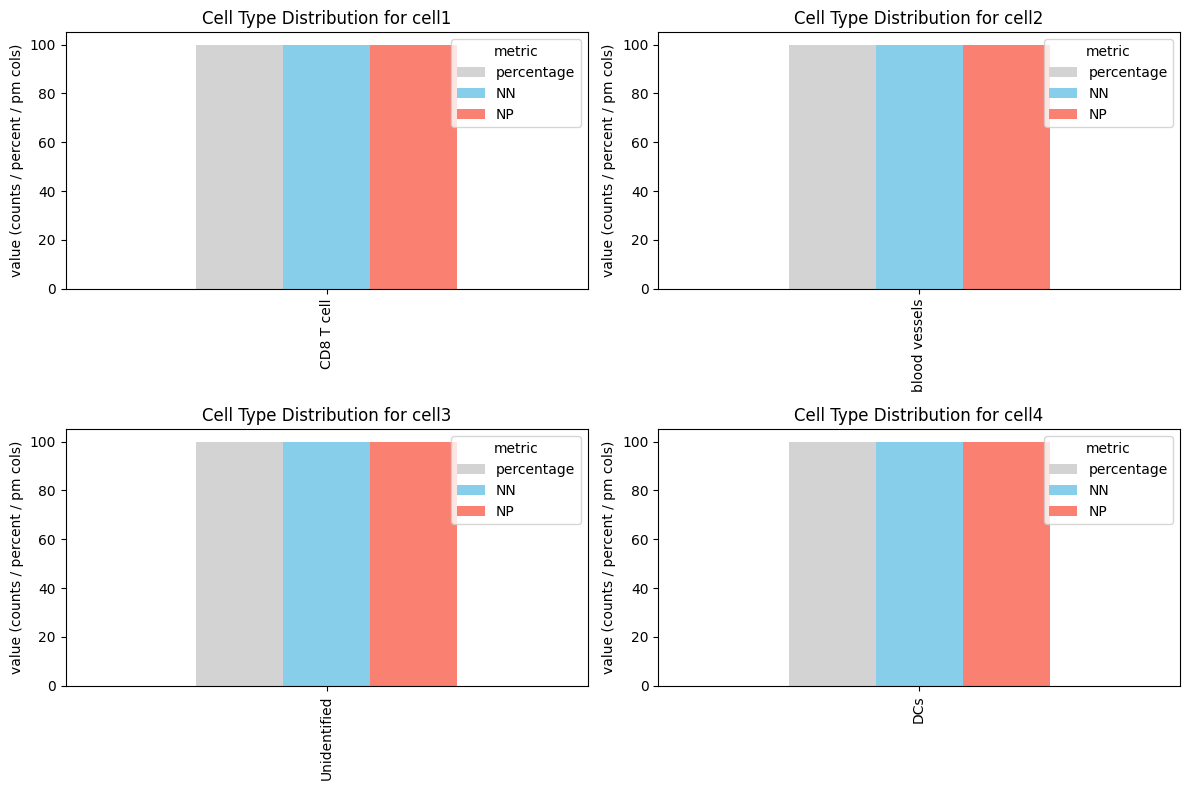

In [165]:
hits = pd.read_csv("motif_hits_wide.csv")
#melanoma_cells = melanoma_cells[melanoma_cells['Group'].isin(['NN', 'NP'])]
analyze_cell_type(melanoma_cells, hits, groups = ['NN','NP'], pms = percent_counts, color_map = group_colors, pred_map = pred_map)        


In [153]:
percent_counts[percent_counts['pred_mapped'] == 'stroma']

Group,pred_mapped,pred,NN,NP,PN,PP
21,stroma,Collagen,22.198785,24.547658,30.153374,39.739002
22,stroma,Collagen_sma,43.899764,39.458805,46.687117,42.012208
23,stroma,SMA,33.901451,35.993538,23.159509,18.248790
